# BrandRadar — Layout Generator V3

Este cuaderno analiza una pieza visual desde dos niveles:

1. **Detección estructural:** identifica bloques visuales aproximados.
2. **Interpretación de layout:** explica cómo está construida la pieza.

No genera heatmaps visuales. El objetivo es producir wireframes e interpretación compositiva.


In [1]:
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageFilter, ImageDraw
from google.colab import files
import re
import math

!apt-get update -qq
!apt-get install -y tesseract-ocr tesseract-ocr-spa
!pip install pytesseract


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-spa
0 upgraded, 1 newly installed, 0 to remove and 9 not upgraded.
Need to get 951 kB of archives.
After this operation, 2,309 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-spa all 1:4.00~git30-7274cfa-1.1 [951 kB]
Fetched 951 kB in 0s (10.0 MB/s)
Selecting previously unselected package tesseract-ocr-spa.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-spa_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-spa (1:4.00~git30-7274cfa-1.1) ...

## 1. Upload del asset


Saving 1.png to 1.png


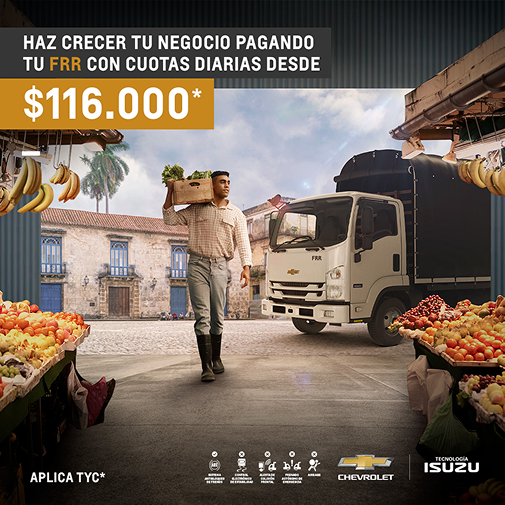

In [13]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert('RGB')
image


## 2. OCR opcional


In [14]:
def try_ocr(img):
    try:
        import pytesseract
        return pytesseract.image_to_data(
            img,
            output_type=pytesseract.Output.DATAFRAME,
            lang='eng+spa'
        )
    except Exception as e:
        print('OCR unavailable:', e)
        return None

ocr_df = try_ocr(image)
ocr_df.head() if ocr_df is not None else 'OCR unavailable'


,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
0,1,1,0,0,0,0,0,0,505,505,-1,NaN
1,2,1,1,0,0,0,23,35,297,36,-1,NaN
2,3,1,1,1,0,0,23,35,297,36,-1,NaN
3,4,1,1,1,1,0,24,35,290,15,-1,NaN
4,5,1,1,1,1,1,24,35,32,14,93,HAZ


## 3. Señales globales de texto


In [15]:
def extract_text_signals(ocr_df):
    if ocr_df is None or 'text' not in ocr_df.columns:
        return {
            'ocr_available': False,
            'word_count': 0,
            'number_count': 0,
            'cta_hits': 0,
            'text_blocks': 0,
        }

    df = ocr_df.dropna(subset=['text']).copy()
    df['text'] = df['text'].astype(str).str.strip()
    df = df[df['text'] != '']

    text = ' '.join(df['text'].tolist())
    words = re.findall(r'\b\w+\b', text)
    numbers = re.findall(r'\d+', text)

    cta_patterns = [
        r'shop', r'buy', r'now', r'sale', r'off', r'save', r'free',
        r'compra', r'ahora', r'oferta', r'descuento', r'aplica',
        r'%', r'\$', r'\d+%'
    ]

    cta_hits = sum(len(re.findall(p, text, flags=re.IGNORECASE)) for p in cta_patterns)

    return {
        'ocr_available': True,
        'word_count': len(words),
        'number_count': len(numbers),
        'cta_hits': cta_hits,
        'text_blocks': len(df),
    }

text_signals = extract_text_signals(ocr_df)
text_signals


{'ocr_available': True,
 'word_count': 9,
 'number_count': 0,
 'cta_hits': 0,
 'text_blocks': 9}

## 4. Grid interno de actividad visual


In [16]:
def normalize(values):
    values = np.array(values, dtype=float)
    if values.max() - values.min() < 1e-9:
        return np.zeros_like(values)
    return (values - values.min()) / (values.max() - values.min())

gray_img = ImageOps.grayscale(image)
edge_img = gray_img.filter(ImageFilter.FIND_EDGES)

gray = np.array(gray_img) / 255.0
edges = np.array(edge_img) / 255.0
H, W = gray.shape

GX = 8
GY = 10
cells = []

for gy in range(GY):
    for gx in range(GX):
        x0 = int(gx * W / GX)
        x1 = int((gx + 1) * W / GX)
        y0 = int(gy * H / GY)
        y1 = int((gy + 1) * H / GY)

        cell_gray = gray[y0:y1, x0:x1]
        cell_edges = edges[y0:y1, x0:x1]

        contrast = cell_gray.std()
        edge_density = cell_edges.mean()
        activity = contrast * 0.55 + edge_density * 0.45

        cells.append({
            'gx': gx,
            'gy': gy,
            'x0': x0,
            'y0': y0,
            'x1': x1,
            'y1': y1,
            'contrast': contrast,
            'edge_density': edge_density,
            'activity': activity,
        })

cells = pd.DataFrame(cells)
cells['activity_n'] = normalize(cells['activity'])
cells.head()


,gx,gy,x0,y0,x1,y1,contrast,edge_density,activity,activity_n
0,0,0,0,0,63,50,0.232639,0.094840,0.170629,0.605040
1,1,0,63,0,126,50,0.307223,0.156865,0.239562,0.881336
2,2,0,126,0,189,50,0.279195,0.134307,0.213995,0.778859
3,3,0,189,0,252,50,0.281835,0.141074,0.218493,0.796885
4,4,0,252,0,315,50,0.289236,0.157160,0.229802,0.842215


## 5. Detección de bloques compositivos


In [17]:
def detect_blocks(cells, threshold=0.58):
    active = cells[cells['activity_n'] >= threshold].copy()
    if active.empty:
        return []

    active_lookup = {(int(r.gx), int(r.gy)): r for _, r in active.iterrows()}
    visited = set()
    blocks = []

    for key in list(active_lookup.keys()):
        if key in visited:
            continue

        stack = [key]
        component = []

        while stack:
            current = stack.pop()
            if current in visited:
                continue
            visited.add(current)
            component.append(active_lookup[current])

            gx, gy = current
            for n in [(gx+1,gy),(gx-1,gy),(gx,gy+1),(gx,gy-1)]:
                if n in active_lookup and n not in visited:
                    stack.append(n)

        xs0 = [int(c.x0) for c in component]
        ys0 = [int(c.y0) for c in component]
        xs1 = [int(c.x1) for c in component]
        ys1 = [int(c.y1) for c in component]
        scores = [float(c.activity_n) for c in component]

        blocks.append({
            'x0': min(xs0),
            'y0': min(ys0),
            'x1': max(xs1),
            'y1': max(ys1),
            'score': float(np.mean(scores)),
            'cell_count': len(component),
        })

    return sorted(blocks, key=lambda b: (b['cell_count'], b['score']), reverse=True)

blocks = detect_blocks(cells)
blocks[:10]


[{'x0': 0,
  'y0': 0,
  'x1': 505,
  'y1': 404,
  'score': 0.7604902153284248,
  'cell_count': 36},
 {'x0': 378,
  'y0': 101,
  'x1': 505,
  'y1': 202,
  'score': 0.7930624618268887,
  'cell_count': 3},
 {'x0': 189,
  'y0': 454,
  'x1': 378,
  'y1': 505,
  'score': 0.6609472644718233,
  'cell_count': 3},
 {'x0': 315,
  'y0': 151,
  'x1': 378,
  'y1': 202,
  'score': 0.7782262903702283,
  'cell_count': 1},
 {'x0': 441,
  'y0': 454,
  'x1': 505,
  'y1': 505,
  'score': 0.5911256166901763,
  'cell_count': 1}]

## 6. Clasificación semántica de bloques


In [18]:
def classify_block(block, image_size, text_signals):
    W, H = image_size
    x0, y0, x1, y1 = block['x0'], block['y0'], block['x1'], block['y1']
    bw = x1 - x0
    bh = y1 - y0
    area_ratio = (bw * bh) / (W * H)
    cx = (x0 + x1) / 2 / W
    cy = (y0 + y1) / 2 / H

    if cy < 0.22 and bw / W > 0.35:
        return 'Headline'
    if cy > 0.82:
        return 'Footer / Legal'
    if text_signals['cta_hits'] > 0 and cy > 0.55 and area_ratio < 0.18:
        return 'CTA / Promo Block'
    if area_ratio > 0.16 or bh / H > 0.32:
        return 'Hero / Main Visual'
    if 0.30 <= cy <= 0.78 and area_ratio > 0.06:
        return 'Product / Brand Object'
    if text_signals['word_count'] > 30 and area_ratio < 0.08:
        return 'Body Copy'
    return 'Secondary Visual'

classified_blocks = []
for b in blocks:
    b = b.copy()
    b['type'] = classify_block(b, (W,H), text_signals)
    classified_blocks.append(b)

classified_blocks[:10]


[{'x0': 0,
  'y0': 0,
  'x1': 505,
  'y1': 404,
  'score': 0.7604902153284248,
  'cell_count': 36,
  'type': 'Hero / Main Visual'},
 {'x0': 378,
  'y0': 101,
  'x1': 505,
  'y1': 202,
  'score': 0.7930624618268887,
  'cell_count': 3,
  'type': 'Secondary Visual'},
 {'x0': 189,
  'y0': 454,
  'x1': 378,
  'y1': 505,
  'score': 0.6609472644718233,
  'cell_count': 3,
  'type': 'Footer / Legal'},
 {'x0': 315,
  'y0': 151,
  'x1': 378,
  'y1': 202,
  'score': 0.7782262903702283,
  'cell_count': 1,
  'type': 'Secondary Visual'},
 {'x0': 441,
  'y0': 454,
  'x1': 505,
  'y1': 505,
  'score': 0.5911256166901763,
  'cell_count': 1,
  'type': 'Footer / Legal'}]

## 7. Overlay sobre imagen original


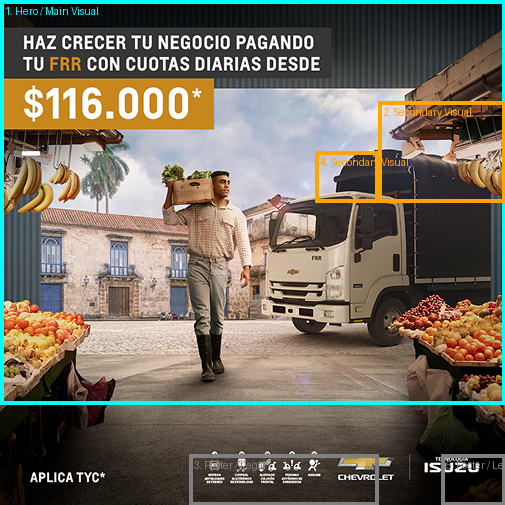

In [19]:
def draw_overlay(image, blocks, max_blocks=8):
    img = image.copy()
    draw = ImageDraw.Draw(img)
    colors = {
        'Headline': 'yellow',
        'Hero / Main Visual': 'cyan',
        'Product / Brand Object': 'lime',
        'CTA / Promo Block': 'red',
        'Body Copy': 'white',
        'Footer / Legal': 'gray',
        'Secondary Visual': 'orange',
    }
    for i,b in enumerate(blocks[:max_blocks], start=1):
        color = colors.get(b['type'], 'white')
        draw.rectangle([b['x0'], b['y0'], b['x1'], b['y1']], outline=color, width=4)
        draw.text((b['x0']+5, b['y0']+5), f"{i}. {b['type']}", fill=color)
    return img

overlay = draw_overlay(image, classified_blocks)
overlay


## 8. Wireframe limpio sin imagen


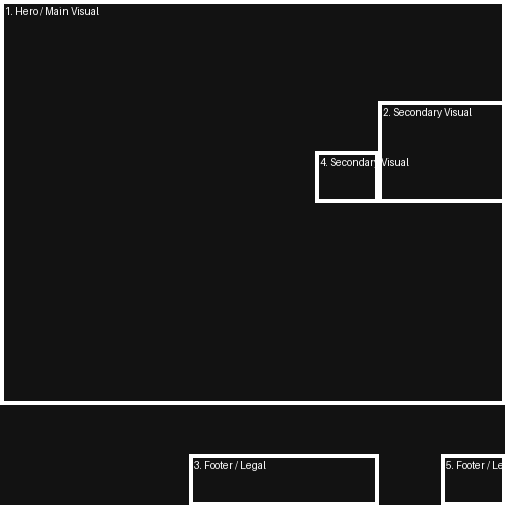

In [20]:
def draw_wireframe(image_size, blocks, max_blocks=8):
    W,H = image_size
    wire = Image.new('RGB', (W,H), (18,18,18))
    draw = ImageDraw.Draw(wire)
    for i,b in enumerate(blocks[:max_blocks], start=1):
        draw.rectangle([b['x0'], b['y0'], b['x1'], b['y1']], outline='white', width=4)
        draw.text((b['x0']+5, b['y0']+5), f"{i}. {b['type']}", fill='white')
    return wire

wireframe = draw_wireframe((W,H), classified_blocks)
wireframe


## 9. Interpretación estructural del layout


In [21]:
def estimate_layout_properties(blocks, text_signals, image_size):
    W,H = image_size
    if not blocks:
        return {
            'framework': 'Unknown',
            'composition': 'undetected',
            'dominant_element': None,
            'layout_complexity': 'low',
            'focus_behavior': 'undetected',
            'commercial_structure': 'unknown',
        }

    types = [b['type'] for b in blocks]
    type_counts = pd.Series(types).value_counts().to_dict()

    scored = []
    for b in blocks:
        area_ratio = ((b['x1']-b['x0'])*(b['y1']-b['y0']))/(W*H)
        hierarchy_score = b['score']*0.55 + area_ratio*3*0.35
        if b['type'] in ['Headline','CTA / Promo Block','Hero / Main Visual']:
            hierarchy_score += 0.10
        scored.append((hierarchy_score,b))
    scored = sorted(scored, key=lambda x:x[0], reverse=True)
    dominant = scored[0][1]

    cx_values = [((b['x0']+b['x1'])/2)/W for b in blocks]
    cy_values = [((b['y0']+b['y1'])/2)/H for b in blocks]
    x_spread = max(cx_values)-min(cx_values) if len(cx_values)>1 else 0
    y_spread = max(cy_values)-min(cy_values) if len(cy_values)>1 else 0

    if y_spread > x_spread:
        composition = 'vertical hierarchy'
    elif x_spread > y_spread:
        composition = 'horizontal / split structure'
    else:
        composition = 'centered structure'

    block_count = len(blocks)
    if block_count <= 3:
        complexity = 'low'
    elif block_count <= 7:
        complexity = 'medium'
    else:
        complexity = 'high'

    top_score = scored[0][0]
    second_score = scored[1][0] if len(scored)>1 else 0
    dominance_gap = top_score-second_score

    if dominance_gap > 0.25:
        focus_behavior = 'focused'
    elif dominance_gap > 0.10:
        focus_behavior = 'moderately focused'
    else:
        focus_behavior = 'distributed'

    if text_signals['cta_hits'] >= 2 or text_signals['number_count'] >= 4:
        commercial = 'aggressive conversion structure'
    elif text_signals['cta_hits'] >= 1 or text_signals['number_count'] >= 1:
        commercial = 'moderate conversion structure'
    else:
        commercial = 'soft / atmospheric structure'

    has_hero = 'Hero / Main Visual' in types
    has_cta = 'CTA / Promo Block' in types or text_signals['cta_hits'] > 0
    has_headline = 'Headline' in types

    if text_signals['word_count'] > 45 and block_count >= 6:
        framework = 'Poster Dense'
    elif has_cta and text_signals['number_count'] > 0:
        framework = 'Retail Promo'
    elif composition == 'horizontal / split structure' and has_cta:
        framework = 'Split Commercial'
    elif has_hero and has_headline:
        framework = 'Product Showcase'
    elif has_hero:
        framework = 'Hero Centered'
    else:
        framework = 'Editorial Atmospheric'

    hierarchy = [b['type'] for _,b in scored[:5]]

    return {
        'framework': framework,
        'composition': composition,
        'dominant_element': dominant['type'],
        'hierarchy': hierarchy,
        'layout_complexity': complexity,
        'focus_behavior': focus_behavior,
        'commercial_structure': commercial,
    }

layout_interpretation = estimate_layout_properties(classified_blocks, text_signals, (W,H))
layout_interpretation


{'framework': 'Hero Centered',
 'composition': 'vertical hierarchy',
 'dominant_element': 'Hero / Main Visual',
 'hierarchy': ['Hero / Main Visual',
  'Secondary Visual',
  'Secondary Visual',
  'Footer / Legal',
  'Footer / Legal'],
 'layout_complexity': 'medium',
 'focus_behavior': 'focused',
 'commercial_structure': 'soft / atmospheric structure'}

## 10. Lectura ejecutiva del layout


In [22]:
def generate_layout_reading(layout):
    return (
        f"The asset uses a {layout['framework']} framework with a {layout['composition']}. "
        f"The dominant element is {layout['dominant_element']}. "
        f"The visual hierarchy follows: {', '.join(layout['hierarchy'])}. "
        f"Layout complexity is {layout['layout_complexity']}, with {layout['focus_behavior']} attention behavior. "
        f"The commercial structure is {layout['commercial_structure']}."
    )

layout_reading = generate_layout_reading(layout_interpretation)
layout_reading


'The asset uses a Hero Centered framework with a vertical hierarchy. The dominant element is Hero / Main Visual. The visual hierarchy follows: Hero / Main Visual, Secondary Visual, Secondary Visual, Footer / Legal, Footer / Legal. Layout complexity is medium, with focused attention behavior. The commercial structure is soft / atmospheric structure.'

## 11. Output final para BrandRadar


In [23]:
layout_output = {
    'layout': layout_interpretation,
    'reading': layout_reading,
    'elements': [
        {
            'type': b['type'],
            'box': [b['x0'], b['y0'], b['x1'], b['y1']],
            'score': round(b['score'],3),
        }
        for b in classified_blocks[:8]
    ]
}

layout_output


{'layout': {'framework': 'Hero Centered',
  'composition': 'vertical hierarchy',
  'dominant_element': 'Hero / Main Visual',
  'hierarchy': ['Hero / Main Visual',
   'Secondary Visual',
   'Secondary Visual',
   'Footer / Legal',
   'Footer / Legal'],
  'layout_complexity': 'medium',
  'focus_behavior': 'focused',
  'commercial_structure': 'soft / atmospheric structure'},
 'reading': 'The asset uses a Hero Centered framework with a vertical hierarchy. The dominant element is Hero / Main Visual. The visual hierarchy follows: Hero / Main Visual, Secondary Visual, Secondary Visual, Footer / Legal, Footer / Legal. Layout complexity is medium, with focused attention behavior. The commercial structure is soft / atmospheric structure.',
 'elements': [{'type': 'Hero / Main Visual',
   'box': [0, 0, 505, 404],
   'score': 0.76},
  {'type': 'Secondary Visual', 'box': [378, 101, 505, 202], 'score': 0.793},
  {'type': 'Footer / Legal', 'box': [189, 454, 378, 505], 'score': 0.661},
  {'type': 'Seco